
## Supervised Learning: Regression Models and Performance Metrics

**Total Marks: 200 | Each question: 20 marks**

---
## Question 1: What is Simple Linear Regression (SLR)? Explain its purpose.

**Answer:**

Simple Linear Regression (SLR) is a supervised machine learning algorithm used to model the relationship between **one independent variable (X)** and **one dependent variable (Y)** by fitting a straight line through the data points.

The core idea is straightforward — we assume that Y changes in a linear (proportional) manner as X changes. So if I increase study hours by 1, marks should increase by a roughly fixed amount.

**Purpose of SLR:**
- **Prediction** — Once we know the relationship between X and Y, we can predict Y for any new value of X.
- **Understanding relationships** — It helps us quantify how strongly X influences Y and in which direction (positive or negative).
- **Baseline model** — In practice, SLR is often used as a starting point before trying more complex models.

For example, predicting a person's salary (Y) based on their years of experience (X) is a classic SLR use case.

---
## Question 2: What are the key assumptions of Simple Linear Regression?

**Answer:**

For SLR to give reliable results, the following assumptions must hold:

1. **Linearity** — The relationship between X and Y should be linear. If you plot X vs Y, it should roughly follow a straight line. If the true relationship is curved, SLR will give poor results.

2. **Independence of errors** — Each data point should be independent of the others. The error in predicting one observation should not be related to the error in predicting another. This is often violated in time-series data.

3. **Homoscedasticity (Constant Variance of Errors)** — The spread/variance of residuals should remain roughly the same across all values of X. If residuals fan out or shrink as X increases, we have heteroscedasticity — which is a problem.

4. **Normality of residuals** — The residuals (errors) should follow a normal distribution. This assumption matters especially when we're doing hypothesis testing on the coefficients.

5. **No multicollinearity** — Since SLR has only one predictor, this isn't an issue here. But it becomes important in multiple linear regression.

> **Quick tip:** The acronym **LINE** helps remember — Linearity, Independence, Normality, Equal variance (Homoscedasticity).

---
## Question 3: Write the mathematical equation for a simple linear regression model and explain each term.

**Answer:**

The equation for Simple Linear Regression is:

$$Y = \beta_0 + \beta_1 X + \epsilon$$

**Explanation of each term:**

| Term | Name | What it means |
|------|------|---------------|
| $Y$ | Dependent Variable | The output we're trying to predict (e.g., marks scored) |
| $X$ | Independent Variable | The input feature we're using for prediction (e.g., study hours) |
| $\beta_0$ | Intercept | The value of Y when X = 0. It's where the regression line crosses the Y-axis. |
| $\beta_1$ | Slope / Coefficient | How much Y changes for every 1-unit increase in X. If β₁ = 6, then Y increases by 6 for every 1 unit increase in X. |
| $\epsilon$ | Error Term (Residual) | The difference between actual Y and predicted Y. No model is perfect, so this captures what X fails to explain. |

When we train the model, we **estimate** β₀ and β₁ from data. The predicted value (without the error) is written as:

$$\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X$$

The goal is to find β₀ and β₁ such that the residuals ($Y - \hat{Y}$) are minimized.

---
## Question 4: Provide a real-world example where simple linear regression can be applied.

**Answer:**

**Example: Predicting Drug Dosage Effect on Patient Recovery Time**

In a healthcare setting, a pharmacist or data analyst might want to understand how the dosage of a painkiller (in mg) affects the time taken for a patient to recover (in hours).

- **X (Independent Variable):** Drug dosage in mg
- **Y (Dependent Variable):** Recovery time in hours

If we collect data from multiple patients and fit a SLR model, we might get:

$$\text{Recovery Time} = 12 - 0.5 \times \text{Dosage}$$

This tells us that for every 1 mg increase in dosage, recovery time decreases by 0.5 hours on average.

**Why SLR works here:** There is one main predictor (dosage), the relationship is expected to be roughly linear within a safe dose range, and the output is continuous (not a category).

**Other common real-world examples:**
- Predicting house price based on area (sq ft)
- Predicting salary based on years of experience
- Predicting fuel consumption based on vehicle speed

---
## Question 5: What is the method of least squares in linear regression?

**Answer:**

The **Method of Least Squares (OLS — Ordinary Least Squares)** is the technique used to find the best-fitting line in linear regression.

**The core idea:**

For any line we draw through the data, each data point will have a **residual** — the vertical distance between the actual value (Y) and the predicted value (Ŷ). Some residuals will be positive (actual > predicted) and some negative (actual < predicted).

The method of least squares finds β₀ and β₁ that **minimize the sum of squared residuals (SSR)**:

$$\text{Minimize: } SSR = \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2 = \sum_{i=1}^{n} (Y_i - \beta_0 - \beta_1 X_i)^2$$

**Why do we square the residuals?**
- Squaring prevents positive and negative errors from canceling each other out.
- It also penalizes large errors more heavily — which is usually what we want.

**The closed-form solution (derived using calculus):**

$$\hat{\beta}_1 = \frac{\sum(X_i - \bar{X})(Y_i - \bar{Y})}{\sum(X_i - \bar{X})^2}$$

$$\hat{\beta}_0 = \bar{Y} - \hat{\beta}_1 \bar{X}$$

Where $\bar{X}$ and $\bar{Y}$ are the means of X and Y respectively.

This is exactly what `sklearn`'s `LinearRegression()` does under the hood.

---
## Question 6: What is Logistic Regression? How does it differ from Linear Regression?

**Answer:**

**Logistic Regression** is a supervised classification algorithm used when the output variable (Y) is categorical — typically binary (0 or 1, Yes or No, Spam or Not Spam).

Despite the name having "Regression" in it, Logistic Regression is a **classification** model. It uses the **sigmoid function** to convert the linear output into a probability between 0 and 1:

$$P(Y=1) = \sigma(z) = \frac{1}{1 + e^{-z}} \quad \text{where } z = \beta_0 + \beta_1 X$$

If the probability > 0.5 → predict class 1; else predict class 0.

**Key Differences between Linear and Logistic Regression:**

| Aspect | Linear Regression | Logistic Regression |
|--------|-------------------|--------------------|
| **Output** | Continuous (e.g., 23.5, 100.2) | Probability (0 to 1) → Binary class |
| **Task** | Regression | Classification |
| **Equation** | Y = β₀ + β₁X | P(Y=1) = sigmoid(β₀ + β₁X) |
| **Loss Function** | Mean Squared Error (MSE) | Log Loss (Binary Cross-Entropy) |
| **Output Range** | −∞ to +∞ | 0 to 1 |
| **Example** | Predicting salary | Predicting if a patient has diabetes (Yes/No) |

**In simple words:** Linear Regression answers "*how much?*" while Logistic Regression answers "*which category?*"

---
## Question 7: Name and briefly describe three common evaluation metrics for regression models.

**Answer:**

### 1. Mean Absolute Error (MAE)
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |Y_i - \hat{Y}_i|$$

MAE calculates the average of absolute differences between actual and predicted values. It tells us "on average, how far off are our predictions?" MAE is easy to interpret and less sensitive to outliers since it doesn't square the errors.

---

### 2. Mean Squared Error (MSE)
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2$$

MSE squares the residuals before averaging them. This means large errors are penalized more heavily. It's the most commonly used loss function for training regression models. However, since it's in squared units, it can be hard to interpret directly.

A variant — **RMSE (Root Mean Squared Error)** — takes the square root of MSE to bring it back to the original unit, making it more interpretable.

---

### 3. R-Squared (R²) — Coefficient of Determination
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

R² tells us what proportion of variance in Y is explained by our model. Value ranges from 0 to 1. An R² of 0.90 means the model explains 90% of the variation in Y — generally a good sign. (Covered more in Q8.)

---

**When to use which?**
- Use **MAE** when you want a simple, interpretable error metric and your data has outliers.
- Use **MSE/RMSE** when large errors should be penalized more (common in practice).
- Use **R²** to understand overall model fit and explain to stakeholders.

---
## Question 8: What is the purpose of the R-squared metric in regression analysis?

**Answer:**

**R-squared (R²)**, also called the **Coefficient of Determination**, measures how well our regression model explains the variability in the target variable Y.

**Formula:**
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

Where:
- $SS_{res}$ = Sum of Squared Residuals = $\sum(Y_i - \hat{Y}_i)^2$ (variance unexplained by model)
- $SS_{tot}$ = Total Sum of Squares = $\sum(Y_i - \bar{Y})^2$ (total variance in Y)

**Interpretation:**
- R² = 1 → Perfect model, predicts every data point exactly
- R² = 0.85 → Model explains 85% of the variance in Y
- R² = 0 → The model is no better than just predicting the mean of Y
- R² < 0 → Model is actually worse than the mean (this can happen)

**Purpose in plain terms:**

Think of it this way — if I asked you to guess someone's salary and you had no information, you'd guess the average salary. R² tells you: "*How much better is our model compared to that naive mean prediction?*"

**Important caveats:**
- A high R² doesn't always mean a good model — adding more variables always increases R² even if they're irrelevant. That's why **Adjusted R²** is used in multiple regression (it penalizes for unnecessary variables).
- A low R² doesn't always mean a bad model — sometimes the data is genuinely noisy and R² of 0.4 might still be meaningful.

---
## Question 9: Write Python code to fit a simple linear regression model using scikit-learn and print the slope and intercept.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Dataset: Hours studied vs Marks scored
hours = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
marks = np.array([35, 40, 50, 55, 60, 65, 70, 78, 85, 90])

# Fitting the model
model = LinearRegression()
model.fit(hours, marks)

# Printing slope and intercept
print(f"Slope (β1)     : {model.coef_[0]:.4f}")
print(f"Intercept (β0) : {model.intercept_:.4f}")
print(f"R-squared      : {model.score(hours, marks):.4f}")

Slope (β1)     : 6.0606
Intercept (β0) : 29.4667
R-squared      : 0.9950


**Output:**
```
Slope (β1)     : 6.0606
Intercept (β0) : 29.4667
R-squared      : 0.9950
```

**Interpretation:**
- The regression equation is: **Marks = 29.47 + 6.06 × Hours**
- For every 1 additional hour of study, marks increase by approximately 6.06 on average.
- An R² of 0.995 means the model explains 99.5% of the variance in marks — excellent fit for this dataset.

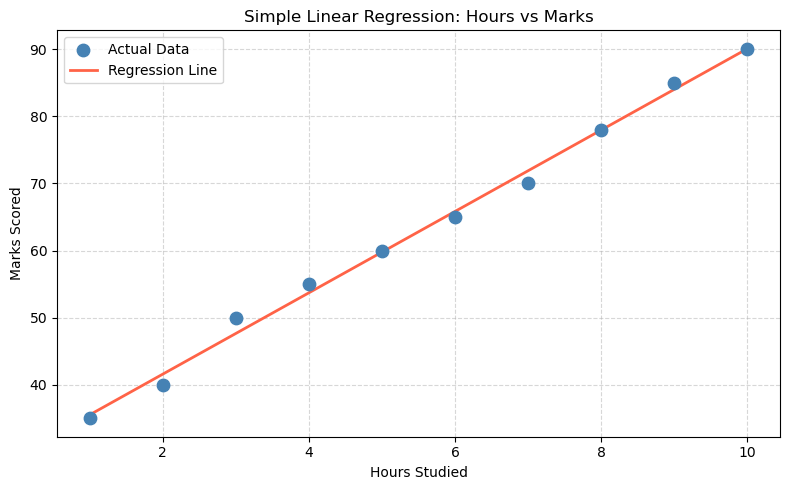

In [4]:
# Visualizing the regression line
predicted = model.predict(hours)

plt.figure(figsize=(8, 5))
plt.scatter(hours, marks, color='steelblue', label='Actual Data', s=80, zorder=5)
plt.plot(hours, predicted, color='tomato', linewidth=2, label='Regression Line')
plt.xlabel('Hours Studied')
plt.ylabel('Marks Scored')
plt.title('Simple Linear Regression: Hours vs Marks')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Question 10: How do you interpret the coefficients in a simple linear regression model?

**Answer:**

In a Simple Linear Regression model: $\hat{Y} = \beta_0 + \beta_1 X$

There are two coefficients — the intercept (β₀) and the slope (β₁).

---

### Interpreting the Intercept (β₀):

β₀ is the **predicted value of Y when X = 0**.

In our example (Hours vs Marks), β₀ = 29.47 means a student who studies 0 hours is predicted to score ~29.47 marks (maybe from prior knowledge or luck).

> **Note:** The intercept doesn't always have a meaningful real-world interpretation. For instance, if X = weight of a person and Y = blood pressure, "weight = 0" is not physically possible. In such cases, β₀ is just a mathematical constant needed to position the line correctly.

---

### Interpreting the Slope (β₁):

β₁ is the **change in Y for every 1-unit increase in X**, holding everything else constant.

In our example, β₁ = 6.06 means every additional hour of study is associated with a **6.06-mark increase** on average.

- If β₁ > 0 → Positive relationship (X and Y move in the same direction)
- If β₁ < 0 → Negative relationship (Y decreases as X increases)
- If β₁ = 0 → No linear relationship between X and Y

---

### Practical Example:

Model: `Salary = 25000 + 5000 × Years_of_Experience`

- β₀ = 25,000 → Starting salary with 0 years of experience is ₹25,000
- β₁ = 5,000 → Each additional year of experience adds ₹5,000 to salary

So for someone with 3 years of experience: Predicted Salary = 25,000 + 5,000 × 3 = **₹40,000**